# Example 4 - an amiguous transit signal with TTVs & GPs

We will refit the model from example 3 with 5 non-consecutive transits, but include GPs and TTVs.

In [16]:
import numpy as np
import pandas as pd
import os
import arviz as az
import matplotlib.pyplot as plt
%matplotlib inline
from MonoTools.MonoTools import fit, tools, lightcurve

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## E4 - Downloading the TESS lightcurve

As for the previous "simple" notebook, we need to do some cleaning due to noisy parts of the most recent TESS sector

Getting all IDs
Accessing online catalogues to match ID to RA/Dec (may be slow) mission= tess
92 91
Sector 92 not (yet) found on MAST | RESPONCE:404
['/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-45_qlplc.h5', '/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-46_qlplc.h5']
['/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-165_qlplc.h5', '/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-166_qlplc.h5']
['/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-179_qlplc.h5', '/Users/hugh/Postdoc/MonoTools_working/TIC00103095888/orbit-180_qlplc.h5']
None


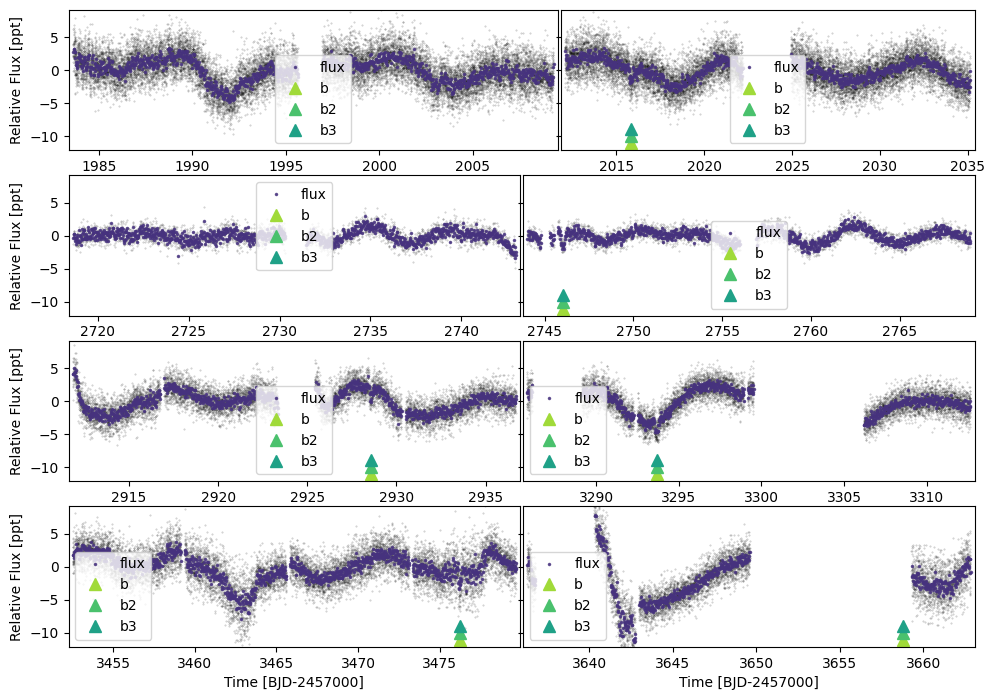

In [4]:
tic=103095888
lc=lightcurve.multilc(tic,'tess',save=False)

lc.mask[abs(lc.time-3654.5)<4.8]=False
lc.mask[abs(lc.time-3638.5)<1.75]=False

lc.remove_binned_arrs()
lc.plot(timeseries=['flux'],plot_ephem={'b':{'p':(2746.02021-2015.81701)/4,'t0':2746.02021},
                    'b2':{'p':(2746.02021-2015.81701)/8,'t0':2746.02021},
                    'b3':{'p':(2746.02021-2015.81701)/20,'t0':2746.02021}},savepng=False)

## E4 - Intialising the ambiguous transit model

In [5]:
mod = fit.monoModel(tic, 'tess', lc=lc)
mod.init_starpars()
mod.add_ambiguous({'tcens':[2015.81701,
                            np.random.normal(2746.02021,0.015),
                            np.random.normal(2928.57101,0.015),
                            np.random.normal(3293.67261,0.015),
                            3476.22341],
                   'tdur':10/48,'depth':1.8e-3},'b')

{'tcens': array([2015.81701   , 2746.05279447, 2928.55541517, 3293.66671314,
       3476.22341   ]), 'tdur': 0.20833333333333334, 'depth': 0.0018, 'span': 1460.4064, 'maxperiod_pair': 1, 'maxperiod': 182.5508, 'p_ratios': array([[[ 8., 16., 24., 32., 40., 48., 56., 64., 72., 80., 88., 96.],
        [ 4.,  8., 12., 16., 20., 24., 28., 32., 36., 40., 44., 48.]],

       [[ 8., 16., 24., 32., 40., 48., 56., 64., 72., 80., 88., 96.],
        [ 5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60.]],

       [[ 8., 16., 24., 32., 40., 48., 56., 64., 72., 80., 88., 96.],
        [ 7., 14., 21., 28., 35., 42., 49., 56., 63., 70., 77., 84.]],

       [[ 8., 16., 24., 32., 40., 48., 56., 64., 72., 80., 88., 96.],
        [ 8., 16., 24., 32., 40., 48., 56., 64., 72., 80., 88., 96.]]]), 'period': 182.5508, 'period_err': 0.034708333333333334, 'period_int_aliases': array([ 8., 16., 24., 32., 40.])}


## E4 - Initialising the lightcurve with GPs

Here we can set `use_GP=True` which means a `celerite` simple harmonic osscilator Gaussian Process will be co-modelled alongside the transit models.

Using `bin_oot=True` and `cut_distance=1.25` means that photometry more than 1.25 transit durations away from the transit centres will be binned (to 30mins).

By default, `train_GP=True`, which means that out-of-transit data is inially fit with a GP. This will help assess the lightcurve GP hyperparameters in order to set relatively constraining priors. These priors can be simple Gaussians, or more complex interpolated functions using `gp_prior_interp=True` (though covariances are ignored).

Another possibility is to set a `periodic_kernel` (`None` by default). Passing a dictionary featuring`period`, `logamp`, `logamp_err` and `periodic_Q` here will initialise a periodic (i.e. stellar rotation) kernel on top of the SHO kernel.

In [6]:
mod.init_lc(use_GP=True, bin_oot=True, cut_distance=1.25, model_ambig_ttv=True,train_GP=True)

[False False False ... False False False]
{'time': (2499,), 'flux': (2499,), 'flux_err': (2499,), 'near_trans': (2499,), 'in_trans': (2499,)}
[False False False ... False False False]
{'time': (5191,), 'flux': (5191,), 'flux_err': (5191,), 'near_trans': (5191,), 'in_trans': (5191,)}
[False False False ... False False False]
{'time': (2288,), 'flux': (2288,), 'flux_err': (2288,), 'near_trans': (2288,), 'in_trans': (2288,)}


## E4 - Initialising the model

### Modelling TTVs for trio/quad/etcs

By stating `model_ambig_ttv=True` we are instead going to model individual transit times and then derive a global period from those. Otherwise, the model fits two transit times (the first and last) and derives intermediate transit times assuming a linear ephemeris and the pre-determined period ratio with respect to the total span

In [140]:
mod.init_model(use_GP=True, bin_oot=True, cut_distance=1.25, model_ambig_ttv=True)

Initialising ~FAST~ MonoTools model.
initialised planet info
Shape.0
Initialised everything. Optimizing


initialising transit
Initalising Transit models for plotting with n_samp= 10
ts_120 successfully interpolated GP means
ts_200 successfully interpolated GP means
ts_600 successfully interpolated GP means
0.2587202715131996


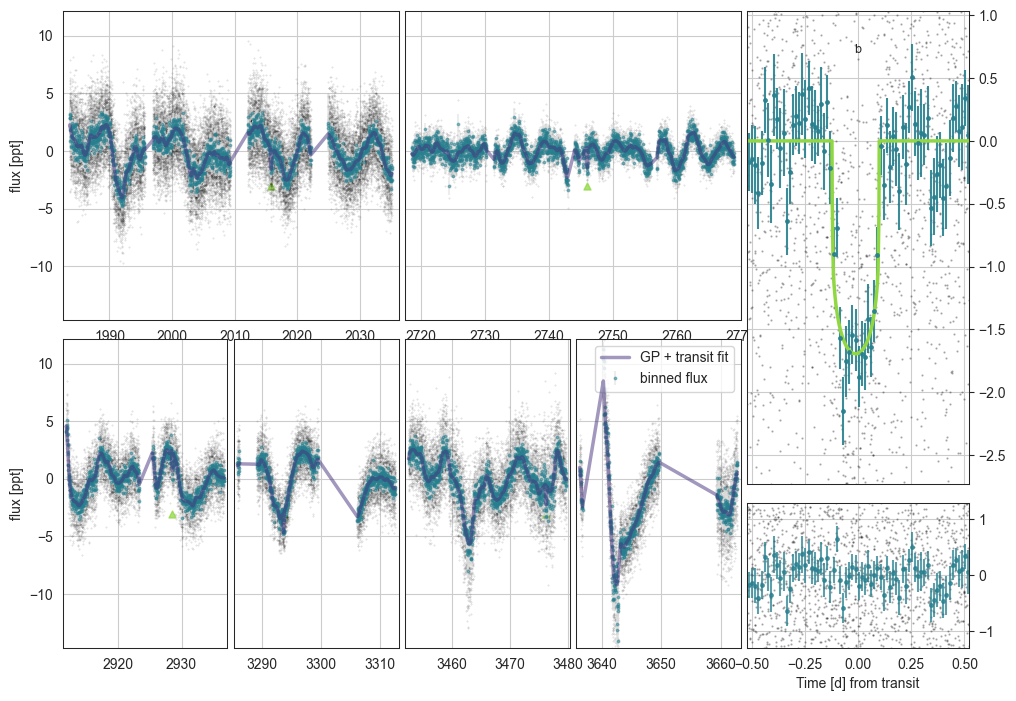

In [137]:
mod.plot()

## E4 - Sampling the model

This is slower than the simple case.

In [142]:
mod.sample_model(overwrite=True, cores=6, n_draws=800)

Multiprocess sampling (6 chains in 6 jobs)
NUTS: [Rs, rhostar, t0_b, logror_b, b_b, tdur_b, q_star_tess, log_jitter_ts_120, phot_mean_ts_120, log_jitter_ts_200, phot_mean_ts_200, log_jitter_ts_600, phot_mean_ts_600, phot_w0, phot_sigma]


Sampling 6 chains for 528 tune and 800 draw iterations (3_168 + 4_800 draws total) took 5079 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 4 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 5 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher n

Saving sampled model parameters to file with shape:  (9257, 14)


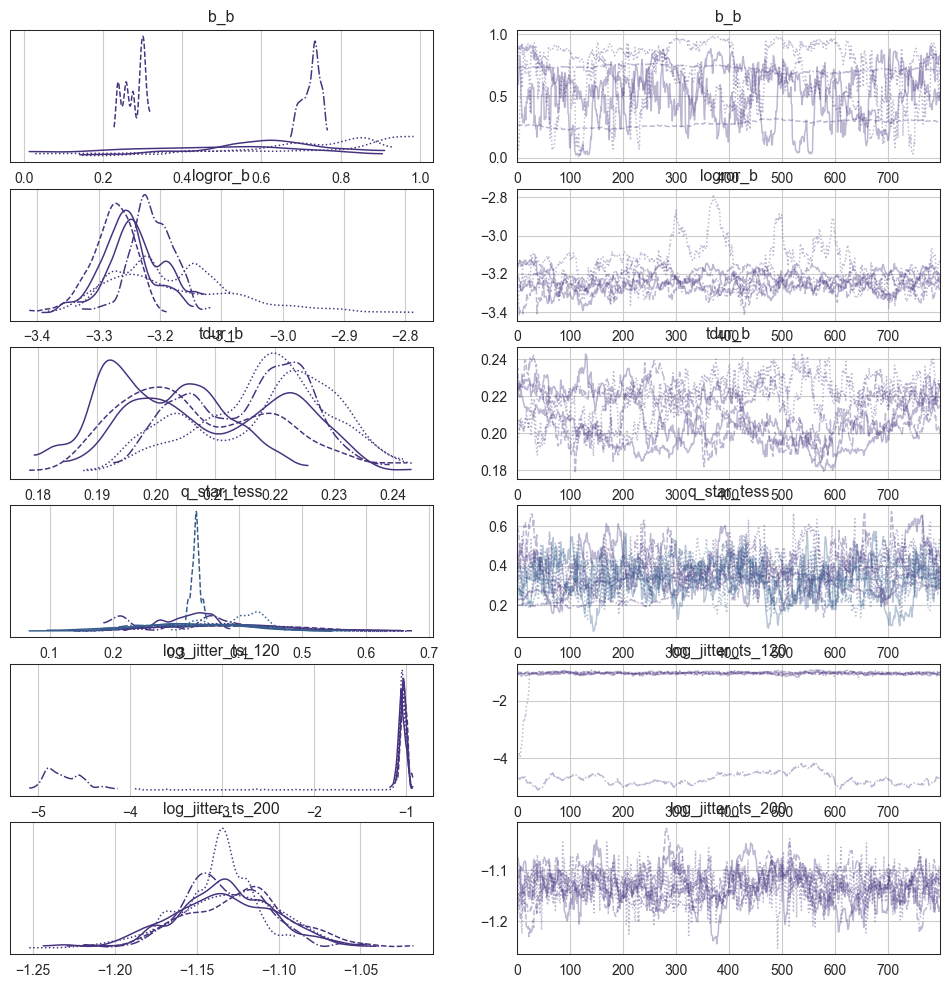

In [149]:
_=az.plot_trace(mod.trace['posterior'], var_names=['b_b','logror_b','tdur_b','q_star_tess','log_jitter_ts_120','log_jitter_ts_200'])
#warmup_posterior

We need _way_ more samples here. But this is just a demo.

variables for Corner: ['Rs', 'rhostar', 'logror_b', 'b_b', 'tdur_b', 't0_b']
['Rs', 'rhostar', 'logror_b', 'b_b', 'tdur_b', 't0_b']


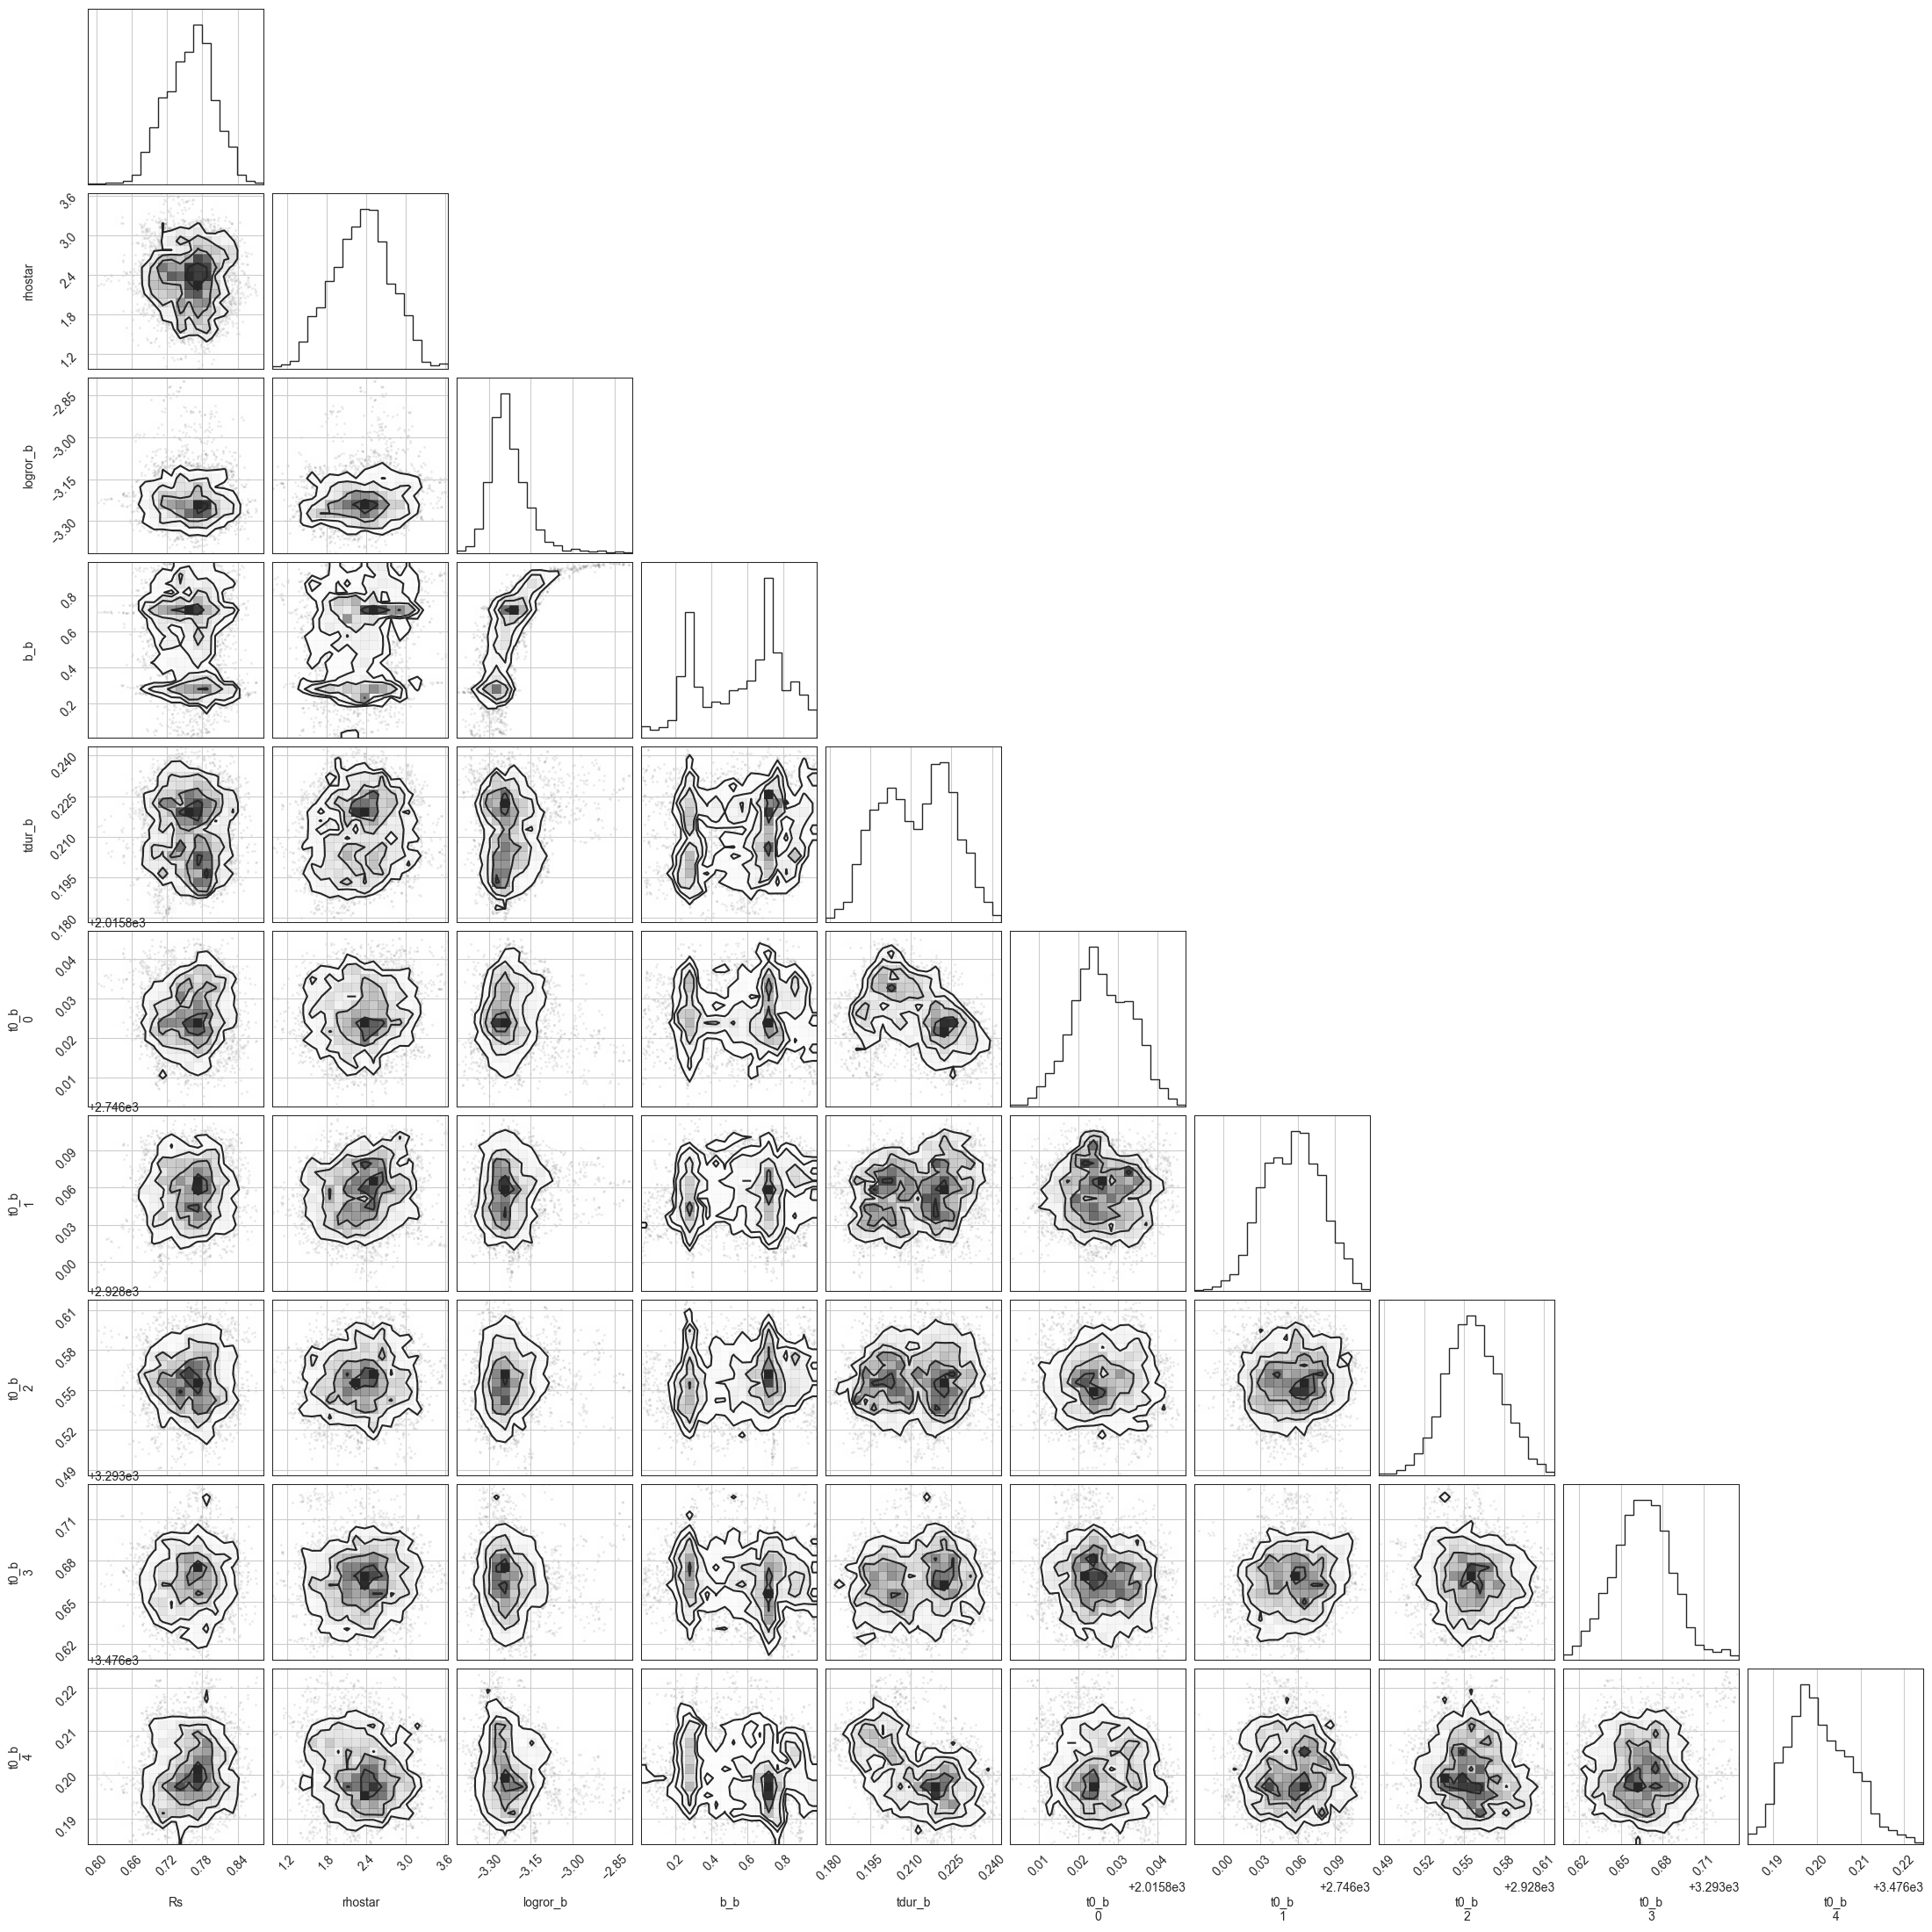

In [150]:
mod.plot_corner()

### E4 - Plotting the best-fit

initialising transit
Initalising Transit models for plotting with n_samp= 990
0.29085769063688505


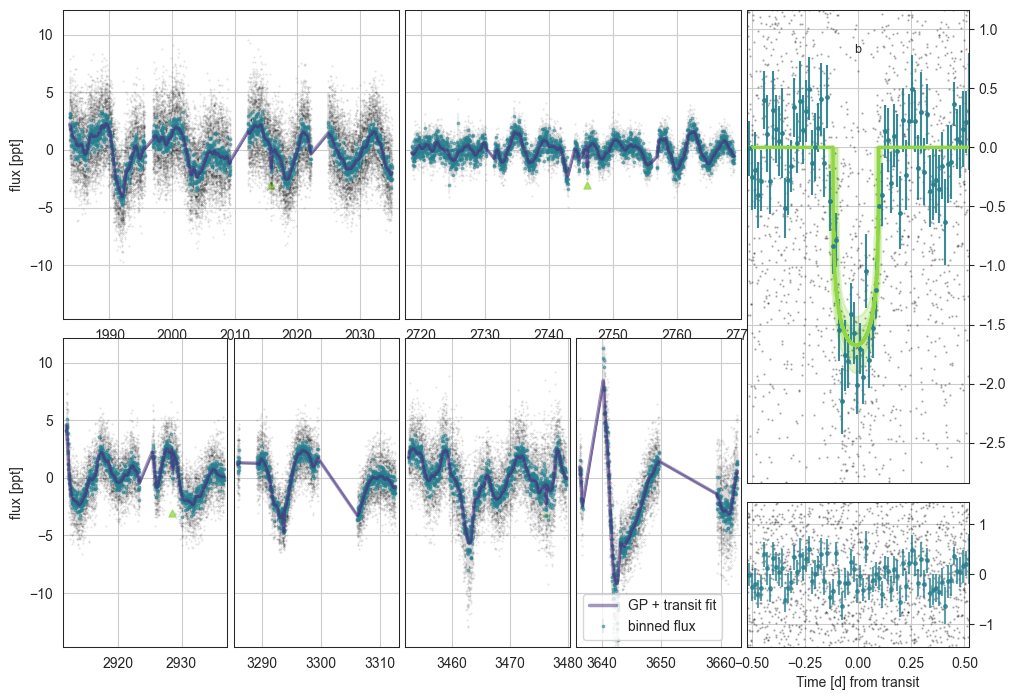

In [153]:
mod.plot()

## E4 - Computing the posterior period probabilities

In [205]:
mod.assess_period_from_posterior()

both__bernmodel auto {'kipping': 'kip', 'vaneylen': 'vve', 'flat': 'flat', 'apogee': 'apo', 'bernmodel_both': 'both__bernmodel', 'bernmodel_sing': 'singles__bernmodel', 'bernmodel_mult': 'multis__bernmodel', 'auto': 'both__bernmodel'} both ['bern', 'auto']


## E4 - Final outputs

### Plotting period aliases:

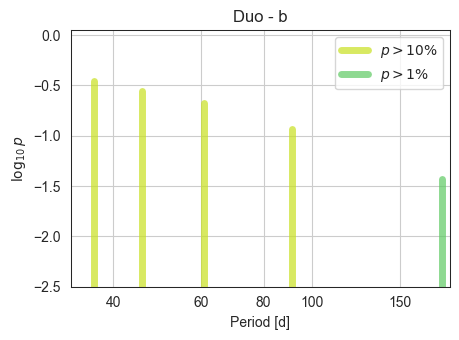

In [207]:
mod.plot_periods(ymin=-2.5)

### Posterior table

In [215]:
mod.make_table()

Saving sampled model parameters to file with shape:  (9314, 14)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,5%,-$1\sigma$,median,+$1\sigma$,95%
Rs,0.75903,0.04050,0.68584,0.83318,0.00316,0.00224,171.01372,579.84759,1.03478,0.69107,0.71511,0.76219,0.79868,0.82463
rhostar,2.33074,0.43892,1.52493,3.12482,0.04886,0.03497,81.43689,167.81385,1.07551,1.58759,1.86375,2.34572,2.77562,3.04480
t0_b[0],2015.82597,0.00735,2015.81237,2015.83956,0.00125,0.00089,36.28396,247.07322,1.14869,2015.81376,2015.81873,2015.82557,2015.83394,2015.83783
t0_b[1],2746.05598,0.02272,2746.01700,2746.09961,0.00372,0.00265,37.89330,95.03845,1.11385,2746.01937,2746.03170,2746.05707,2746.07950,2746.09370
t0_b[2],2928.55699,0.02090,2928.51941,2928.59772,0.00187,0.00133,125.70602,296.18575,1.02444,2928.52335,2928.53611,2928.55628,2928.57823,2928.59301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ecc_marg_av_b,0.30971,0.16610,0.07270,0.65055,0.04126,0.02971,15.81982,34.17540,1.32507,0.12329,0.14933,0.24883,0.42684,0.67428
ecc_marg_sd_b,0.01365,0.00895,0.00419,0.03019,0.00196,0.00141,18.67613,82.13914,1.22990,0.00507,0.00702,0.01110,0.02029,0.03148
vel_marg_b,0.83900,0.17135,0.45918,1.10454,0.04475,0.03336,14.32403,34.47314,1.37040,0.48740,0.71350,0.88434,1.00367,1.06360
per_marg_av_b,56.07264,7.93798,40.63602,68.56733,2.07976,1.50111,13.54872,78.48915,1.39225,41.87952,46.59363,56.45058,62.43775,68.64177


### Lightcurve plot

initialising transit
Initalising Transit models for plotting with n_samp= 990
0.29085769063688505


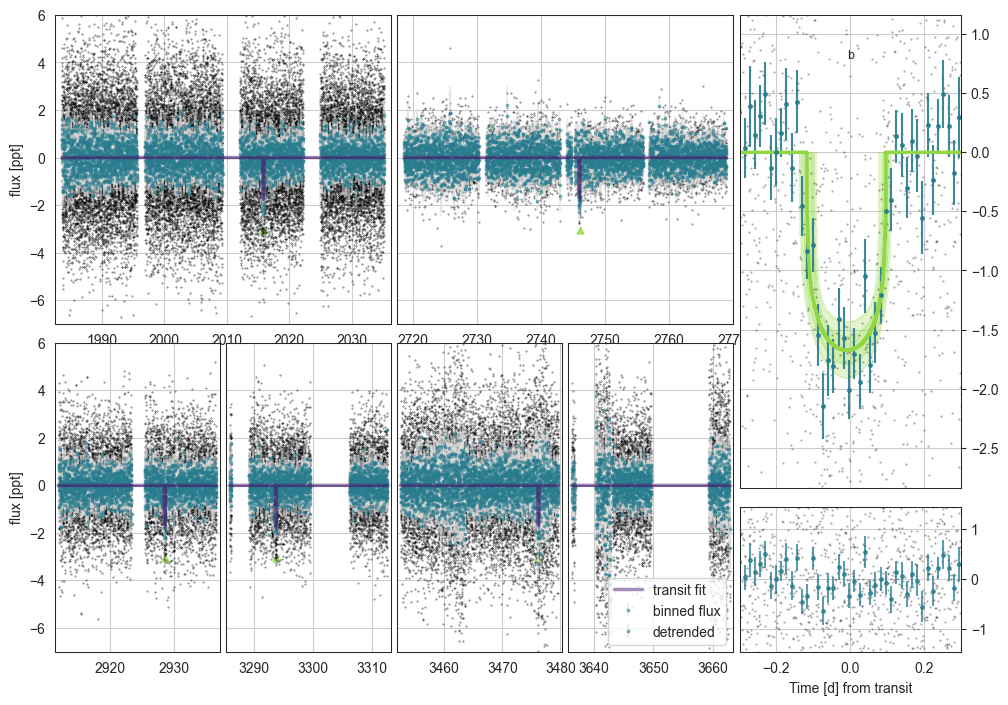

In [196]:
mod.plot(plot_flat=True,ylim=(-7,6),xlim=(-0.3,0.3))

## E4 - Predicting future transits

By default it looks for the next 6 months:

In [208]:
mod.predict_future_transits()

time range 2025-06-05T10:35:57.844 -> 2025-12-02T10:35:57.844


,transit_mid_date,transit_mid_med,transit_dur_med,transit_dur_-1sig,transit_dur_+1sig,transit_start_+2sig,transit_start_+1sig,transit_start_med,transit_start_-1sig,transit_start_-2sig,...,planet_name,alias_n,alias_p,aliases_ns,aliases_ps,total_prob,num_aliases,in_TESS,sun_separation,moon_separation
0,2025-06-14T19:02:22.380,3841.293315,0.212578,0.197078,0.225839,3841.220966,3841.204607,3841.187026,3841.171933,3841.160183,...,duo_b,0,182.546584,"0,1,2,3,4","182.5466,91.2733,60.8489,45.6366,36.5093",1.000000,5.0,False,52.544191,118.327951
1,2025-07-21T07:15:48.020,3877.802639,0.212578,0.197078,0.225839,3877.731026,3877.714099,3877.696350,3877.681083,3877.669042,...,duo_b,4,36.509317,4,36.5093,0.367791,1.0,False,62.345520,47.477300
2,2025-07-30T10:19:09.864,3886.929975,0.212578,0.197078,0.225839,3886.858507,3886.841483,3886.823686,3886.808382,3886.796219,...,duo_b,3,45.636646,3,45.6366,0.289220,1.0,False,66.518755,107.544954
3,2025-08-14T15:24:46.121,3902.142200,0.212578,0.197078,0.225839,3902.070824,3902.053826,3902.035912,3902.020549,3902.008190,...,duo_b,2,60.848861,2,60.8489,0.205339,1.0,False,74.395310,62.280802
4,2025-08-26T19:29:18.326,3914.312018,0.212578,0.197078,0.225839,3914.240677,3914.223660,3914.205729,3914.190277,3914.177786,...,duo_b,4,36.509317,4,36.5093,0.367791,1.0,False,81.262697,107.927690
5,2025-09-14T01:36:01.307,3932.566682,0.212578,0.197078,0.225839,3932.495460,3932.478442,3932.460393,3932.444825,3932.432142,...,duo_b,1,91.273292,"1,3","91.2733,45.6366",0.411575,2.0,False,92.017277,47.053472
6,2025-10-02T07:42:45.018,3950.821354,0.212578,0.197078,0.225839,3950.750449,3950.733243,3950.715066,3950.699338,3950.686588,...,duo_b,4,36.509317,4,36.5093,0.367791,1.0,False,102.752449,117.097146
7,2025-10-14T11:47:14.205,3962.991137,0.212578,0.197078,0.225839,3962.920469,3962.903098,3962.884848,3962.869048,3962.856144,...,duo_b,2,60.848861,2,60.8489,0.205339,1.0,False,109.542422,59.746670
8,2025-10-29T16:52:50.382,3978.203361,0.212578,0.197078,0.225839,3978.132993,3978.115408,3978.097072,3978.081168,3978.068057,...,duo_b,3,45.636646,3,45.6366,0.289220,1.0,False,117.160653,116.725954
9,2025-11-07T19:56:11.882,3987.330693,0.212578,0.197078,0.225839,3987.260508,3987.242770,3987.224404,3987.208457,3987.195162,...,duo_b,4,36.509317,4,36.5093,0.367791,1.0,False,121.013362,47.249288


In [209]:
df = mod.make_table()
df

Saving sampled model parameters to file with shape:  (9314, 14)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,5%,-$1\sigma$,median,+$1\sigma$,95%
Rs,0.75903,0.04050,0.68584,0.83318,0.00316,0.00224,171.01372,579.84759,1.03478,0.69107,0.71511,0.76219,0.79868,0.82463
rhostar,2.33074,0.43892,1.52493,3.12482,0.04886,0.03497,81.43689,167.81385,1.07551,1.58759,1.86375,2.34572,2.77562,3.04480
t0_b[0],2015.82597,0.00735,2015.81237,2015.83956,0.00125,0.00089,36.28396,247.07322,1.14869,2015.81376,2015.81873,2015.82557,2015.83394,2015.83783
t0_b[1],2746.05598,0.02272,2746.01700,2746.09961,0.00372,0.00265,37.89330,95.03845,1.11385,2746.01937,2746.03170,2746.05707,2746.07950,2746.09370
t0_b[2],2928.55699,0.02090,2928.51941,2928.59772,0.00187,0.00133,125.70602,296.18575,1.02444,2928.52335,2928.53611,2928.55628,2928.57823,2928.59301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ecc_marg_av_b,0.30971,0.16610,0.07270,0.65055,0.04126,0.02971,15.81982,34.17540,1.32507,0.12329,0.14933,0.24883,0.42684,0.67428
ecc_marg_sd_b,0.01365,0.00895,0.00419,0.03019,0.00196,0.00141,18.67613,82.13914,1.22990,0.00507,0.00702,0.01110,0.02029,0.03148
vel_marg_b,0.83900,0.17135,0.45918,1.10454,0.04475,0.03336,14.32403,34.47314,1.37040,0.48740,0.71350,0.88434,1.00367,1.06360
per_marg_av_b,56.07264,7.93798,40.63602,68.56733,2.07976,1.50111,13.54872,78.48915,1.39225,41.87952,46.59363,56.45058,62.43775,68.64177


### E4 - Making a CHEOPS OR

Useful for me. Probably less useful for you.

In [214]:
mod.make_cheops_OR(observe_sigma=6)

INFO: Query finished. [astroquery.utils.tap.core]
time range 2025-08-22T01:12:28.706 -> 2026-02-18T01:12:28.706
SNR for whole transit is:  22.21439642371073
SNR for single orbit in/egress is:  8.887763520815888
2
3
4
Run the following command in a terminal to generate ORs:
"make_xml_files /Users/hugh/Postdoc/MonoTools_working/TIC00103095888/TIC00103095888_2025-06-04_3_output_ORs.csv --auto-expose -f"


,ObsReqName,Target,_RAJ2000,_DEJ2000,pmra,pmdec,parallax,SpTy,Gmag,dr2_g_mag,...,N_Visits,Priority,MinEffDur,Gaia_DR2,BJD_0,Period,Ph_late,Ph_early,Old_T_eff,N_Ranges
0,TIC103095888_b_period60;85_prob0.20,TIC103095888,4:04:32.60347091,74:32:17.3872212,-37.019048,12.694132,7.31134,G9,11.461562,11.461562,...,1,2,45,549939402265939072,2460476.199873,60.848861,0.997126,0.995548,-99.0,0
1,TIC103095888_b_period45;64_prob0.28,TIC103095888,4:04:32.60347091,74:32:17.3872212,-37.019048,12.694132,7.31134,G9,11.461562,11.461562,...,1,2,45,549939402265939072,2460476.199873,45.636646,0.996168,0.994064,-99.0,0
2,TIC103095888_b_period36;51_prob0.36,TIC103095888,4:04:32.60347091,74:32:17.3872212,-37.019048,12.694132,7.31134,G9,11.461562,11.461562,...,1,1,45,549939402265939072,2460476.199873,36.509317,0.99521,0.99258,-99.0,0
